### Classification of oil and gas

**План выполнения задачи классификации**
1. Работа с датасетом (анализ данных и предобработка, feature engineering)
2. Обучение модель с последующим выбором лучшей по f1-score
3. Подбор гиперпараметров для модели

In [69]:
# импортируем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import Image, display
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, make_scorer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [70]:
# считываем датасеты 
data_path = os.path.join('data', '')

train_df = pd.read_csv(os.path.join(data_path, 'train_oil.csv'))
test_df = pd.read_csv(os.path.join(data_path, 'oil_test.csv'))

### EDA

для начала поработаем с самим датасетом - посмотрим на пропуски и типы данных

In [71]:
missing_table = pd.DataFrame({
    'data type': train_df.dtypes,
    'null count': train_df.isnull().sum(),
    'null percantage': (train_df.isnull().sum() / len(train_df) * 100).round(2),
    'unique values': train_df.nunique()
})

# только колонки где есть пропуски 
missing_cols = missing_table[missing_table['null count'] > 0]

display(missing_cols)

,data type,null count,null percantage,unique values
Country,object,27,8.74,42
Region,object,38,12.30,7
Basin name,object,38,12.30,93
Latitude,float64,27,8.74,262
Longitude,float64,30,9.71,260


мы видим, что есть 3 категориальных переменных и 2 числовых переменных с пропусками

далее рассмотрим абсолютную частоту состояний целевой переменной

  ONSHORE 218 (70.55%)
  OFFSHORE 86 (27.83%)
  ONSHORE-OFFSHORE 5 (1.62%)


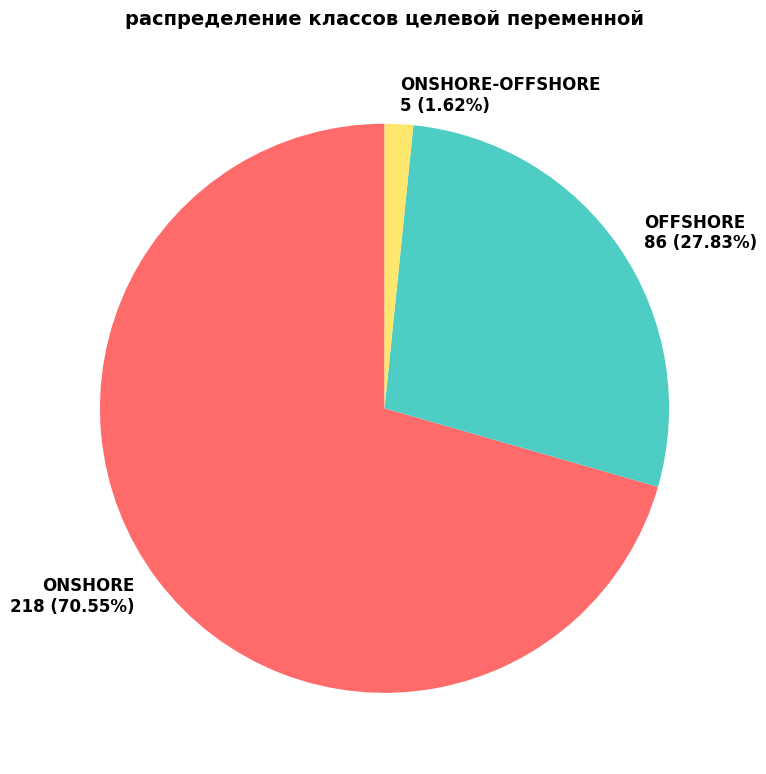

In [72]:
target_counts = train_df['Onshore/Offshore'].value_counts()
target_pct = (train_df['Onshore/Offshore'].value_counts(normalize=True) * 100).round(2)

for cls, count in target_counts.items():
    print(f"  {cls} {count} ({target_pct[cls]}%)")

# круговая диаграмма (отражаем абсолютную частоту классов)
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']  
labels = [f"{cls}\n{count} ({target_pct[cls]}%)" 
          for cls, count in zip(target_counts.index, target_counts.values)]

wedges, texts, autotexts = ax.pie(target_counts.values, 
                                   labels=labels,
                                   colors=colors,
                                   autopct='',
                                   startangle=90,
                                   textprops={'fontsize': 12, 'fontweight': 'bold'})

ax.set_title('распределение классов целевой переменной', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

мы можем заметить, что состояние onshore-offshore очень редкое, так что чтобы не было лишнего шума для модели, мы уберем это состояние

In [73]:
train_df = train_df[train_df['Onshore/Offshore'] != 'ONSHORE-OFFSHORE'].copy()

print("классы после удаления")
print(train_df['Onshore/Offshore'].value_counts())

классы после удаления
Onshore/Offshore
ONSHORE     218
OFFSHORE     86
Name: count, dtype: int64


рассмотрим числовые признаки - приведем описательную статистику и построим boxplot для понимания распределения

,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
count,304.00,304.00,304.00,304.00,304.00
mean,6810.76,737.97,183.30,17.75,479.12
std,3622.97,1308.28,284.33,7.13,1006.57
min,220.00,11.00,2.12,1.10,0.01
25%,4093.75,122.25,43.75,12.00,10.00
50%,6580.00,300.00,101.00,17.00,64.50
75%,9204.75,703.75,205.50,23.15,387.00
max,19888.00,8200.00,2976.00,35.00,7500.00


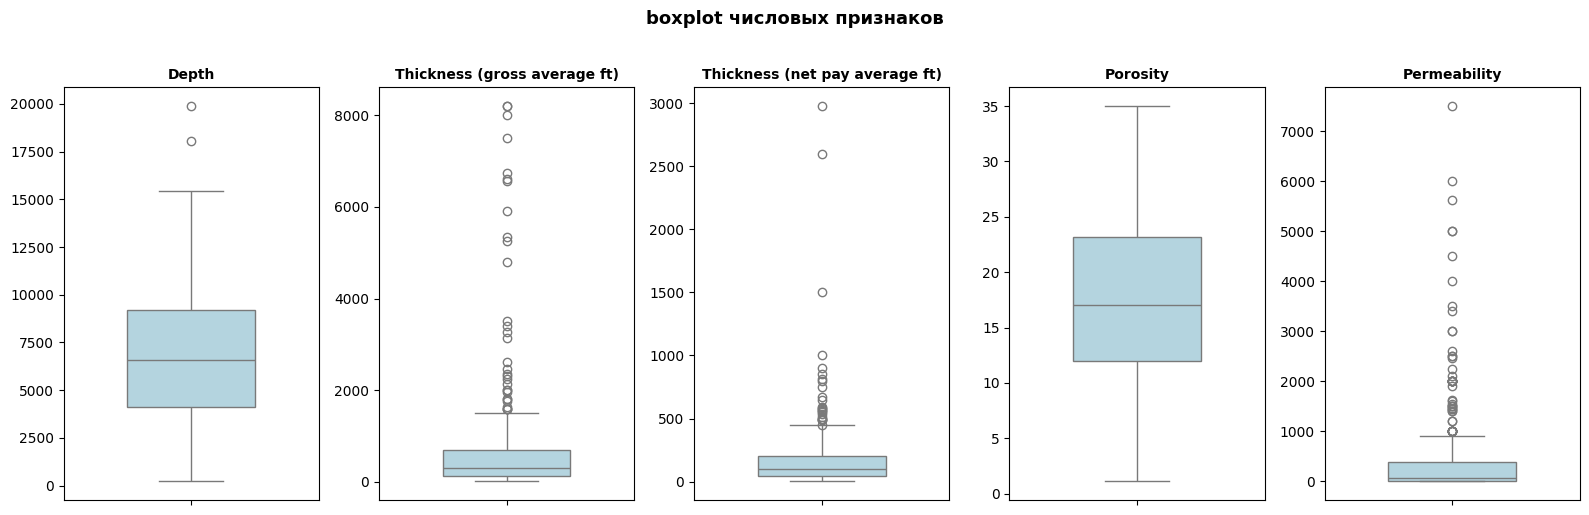

In [74]:
numeric_cols = ['Depth', 'Thickness (gross average ft)', 
                'Thickness (net pay average ft)', 'Porosity', 'Permeability']

# базовая статистика
display(train_df[numeric_cols].describe().round(2))

# boxplot для выявления выбросов
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
for idx, col in enumerate(numeric_cols):
    sns.boxplot(data=train_df, y=col, ax=axes[idx], color='lightblue', width=0.5)
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('')
plt.suptitle('boxplot числовых признаков', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

теперь рассмотрим категориальные переменные (без таргета) - посмотрим на количество уникальных значений в трейне и тесте

In [75]:
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
# убираем таргет
categorical_cols = [col for col in categorical_cols if col != 'Onshore/Offshore']
cat_info = pd.DataFrame({
    'feature': categorical_cols,
    'unique_train': [train_df[col].nunique() for col in categorical_cols],
    'unique_test': [test_df[col].nunique() for col in categorical_cols],
    'has_nulls_train': [train_df[col].isnull().sum() > 0 for col in categorical_cols]
})

# сортируем по убыванию
cat_info = cat_info.sort_values('unique_train', ascending=False)
display(cat_info)

,feature,unique_train,unique_test,has_nulls_train
0,Field name,280,125,False
1,Reservoir unit,255,125,False
6,Operator company,137,81,False
4,Basin name,90,57,True
5,Tectonic regime,55,33,False
9,Structural setting,43,38,False
2,Country,42,30,True
10,Reservoir period,22,21,False
11,Lithology,13,16,False
8,Reservoir status,13,11,False


первые три признака стоит удалить, так как такое большое количество уникальных значений (почти равное количеству строк) может повысить риск переобучения, тк эти строки по сути являются уникальными идентификаторами

### Удаление признаков и создание новых

для начала удалим категориальные переменные, которые могут переобучить модель

In [76]:
cols_to_drop = ['Field name', 'Reservoir unit', 'Operator company']
print(cols_to_drop)

train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

['Field name', 'Reservoir unit', 'Operator company']


далее мы создадим новый признак - географические кластеры, которые разделят комбинации долготы и широты на несколько групп (предположим 5 кластеров как оптимальное разделение)

сначала заполним пропуски для широты и долготы медианой

In [77]:
train_df['Latitude'] = train_df['Latitude'].fillna(train_df['Latitude'].median())
train_df['Longitude'] = train_df['Longitude'].fillna(train_df['Longitude'].median())
test_df['Latitude'] = test_df['Latitude'].fillna(test_df['Latitude'].median())
test_df['Longitude'] = test_df['Longitude'].fillna(test_df['Longitude'].median())

In [78]:
all_coords = pd.concat([
    train_df[['Latitude', 'Longitude']], 
    test_df[['Latitude', 'Longitude']]
], axis=0)

# обучаем KMeans на всех координатах
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
all_clusters = kmeans.fit_predict(all_coords)

# разделяем обратно
train_df['Geo_Cluster'] = all_clusters[:len(train_df)]
test_df['Geo_Cluster'] = all_clusters[len(train_df):]

print(f"распределение по кластерам в train\n{train_df['Geo_Cluster'].value_counts().sort_index()}")

распределение по кластерам в train
Geo_Cluster
0     80
1    108
2     54
3     16
4     46
Name: count, dtype: int64


также построим scatterplot для графического отображения получившихся кластеров

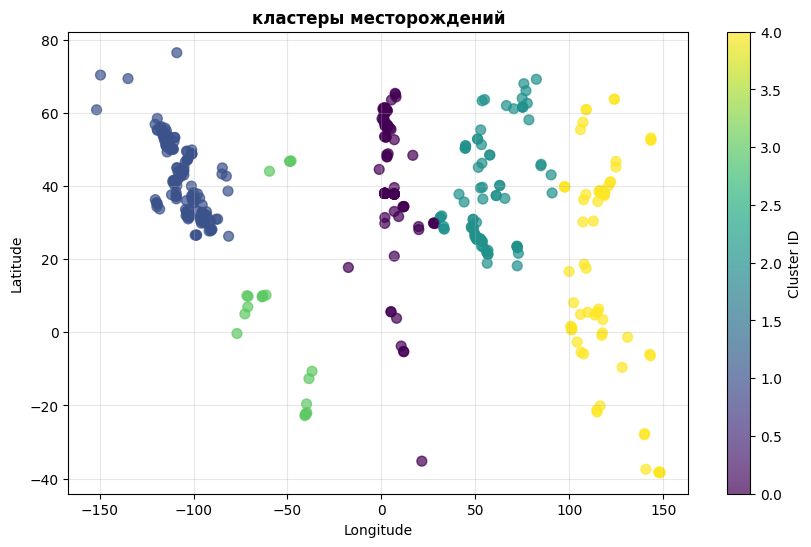

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(all_coords['Longitude'], all_coords['Latitude'], 
                      c=all_clusters, cmap='viridis', alpha=0.7, s=50)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('кластеры месторождений', fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

перед тем как отделить таргет от остальных признаков, сохраним индексы для последующей выгрузки на kaggle

In [80]:
test_index = test_df.index if 'index' not in test_df.columns else test_df['index']

также определим признаки в две группы (по типам данных) для последующей обработки

In [81]:
y = train_df['Onshore/Offshore'].copy()

# убираем таргет
X_train = train_df.drop(columns=['Onshore/Offshore'])
X_test = test_df.copy()  # таргета и так нет в тесте

# типы признаков
numeric_features = ['Depth', 'Thickness (gross average ft)', 
                    'Thickness (net pay average ft)', 'Porosity', 'Permeability',
                    'Latitude', 'Longitude']  

categorical_features = ['Country', 'Region', 'Basin name', 'Tectonic regime',
                        'Hydrocarbon type', 'Reservoir status', 'Structural setting',
                        'Reservoir period', 'Lithology', 'Geo_Cluster']

далее построим два пайплайна обработки, отдально для метрических и категориальных признаков, а также объединяем их в один columntransformer

после применим эту модель на наши данные, также закодируем таргет для корректной работы модели

In [82]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # медиана устойчива к выбросам
    ('scaler', StandardScaler())  # стандартизация для моделей
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),  # заполняем пропуски
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', 
                               unknown_value=-1))  # защита от новых категорий в тесте
])

# объединяем
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)  #  обучаем на трейне
X_test_processed = preprocessor.transform(X_test)  # применяем к тесту

# маппинг для перевода состояний таргета из названий в числа
target_mapping = {
    'OFFSHORE': 0,
    'ONSHORE': 1
}

y_encoded = y.map(target_mapping)

print(f"shape трейна {X_train_processed.shape}")
print(f"shape ткеста {X_test_processed.shape}")
print(f"уникальные классы таргета {np.unique(y_encoded)}")

shape трейна (304, 17)
shape ткеста (133, 17)
уникальные классы таргета [0 1]


### Постройка базовых моделей для выбора наилучшей и последующей работы с ней


In [83]:
# для сохрнения пропорций классов будем использовать фолды
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

построим классические модели классификации (с базовыми гиперпараметрами) и сравним их по f1 score

In [84]:
models = {
    'logistic regression': LogisticRegression(
        max_iter=1000, 
        random_state=42,
        class_weight='balanced'  
    ),
    
    'random forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),
    
    'lightgBM': LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        class_weight='balanced',
        verbose=-1
    ),
    
    'catboost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=5,
        random_seed=42,
        class_weights=[1, 2.5],
        verbose=0,                   
        allow_writing_files=False
    )
}

сохраним результаты в списки для каждого фолда отдельно и среднее по всем фолдам для каждой модели

In [85]:
cv_scores = {}
cv_scores_std = {}

for name, model in models.items():
    print(f"{name}")
    
    # считаем f1 на кросс-валидации
    scores = cross_val_score(
        model, 
        X_train_processed, 
        y_encoded, 
        cv=cv, 
        scoring='f1',
        n_jobs=-1
    )
    
    cv_scores[name] = scores.mean()
    cv_scores_std[name] = scores.std()
    
    print(f"F1 {scores.mean():.4f}")
    print(f"по фолдам {[f'{s:.4f}' for s in scores]}")

logistic regression
F1 0.8491
по фолдам ['0.8537', '0.8571', '0.8434', '0.8706', '0.8205']
random forest
F1 0.9143
по фолдам ['0.9231', '0.9438', '0.9111', '0.9231', '0.8706']
lightgBM
F1 0.9122
по фолдам ['0.9302', '0.9176', '0.8941', '0.9438', '0.8750']
catboost
F1 0.9131
по фолдам ['0.9130', '0.9670', '0.9130', '0.8958', '0.8764']


по итогам получается, что модель random forest получила самую высокую оценку f1

снова разделим данные на фолды и соберем dict гиперпараметров

In [86]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score)

In [87]:
param_dist = {
    'n_estimators': [100, 150, 200, 250],  # количество деревьев
    'max_depth': [5, 7, 10, 12, 15],  # глубина 
    'min_samples_split': [2, 5, 10],  # min объектов для разделения
    'min_samples_leaf': [1, 2, 4],  # min объектов в листе
    'max_features': ['sqrt', 'log2', 0.5],  # количество признаков для разделения
    'class_weight': ['balanced', 'balanced_subsample']  # балансировка классов
}

print(f"параметров для подбора {len(param_dist)}")

параметров для подбора 6


построим бейслайн random forest

In [88]:
base_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

baseline_scores = cross_val_score(base_rf, X_train_processed, y_encoded, 
                                   cv=cv, scoring=scorer, n_jobs=-1)

print(f'средний f1 по фолдам {baseline_scores.mean():.4f}')

средний f1 по фолдам 0.9176


теперь подберем оптимальные гиперпараметры

нужно выбрать критерий подбора, так как у нас очень много комбинаций параметров, а также выборка достаточно маленькая, мы будем использовать randomsearch а не gridsearch (в ином случае у нас это займет очень много времени, а так же есть риск переобучения внутри фолдов)

In [89]:
random_search = RandomizedSearchCV(
    estimator = base_rf,
    param_distributions=param_dist,
    n_iter=30,  # 30 комбинаций
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_processed, y_encoded)

print(f'f1 бейслайна {baseline_scores.mean():.4f}')
print(f'f1 после тюнинга {random_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits
f1 бейслайна 0.9176
f1 после тюнинга 0.9260


f1 скор явно улучшился после тюнинга, рассмотрим какие гиперпараметры были подобраны как оптимальные

In [90]:
for param, value in random_search.best_params_.items():
    print(f"{param} = {value}")

n_estimators = 250
min_samples_split = 10
min_samples_leaf = 1
max_features = log2
max_depth = 12
class_weight = balanced


1. количество деревьев = 250, чем больше деревьев тем лучше предсказание, но при слишком большой количестве деревьев (учитывая маленький размер выборки) прирост бы не происходил
2. минимальное колво объектов в узле = 10, достаточно много чтобы не запоминать шум, предотвращаем создание узлов с 1-2 объектами
3. минимальное колво объектов в листе = 1, выглядит как повод для переобучения, НО если посмотреть на min samples split, то в каждом листе будет по +-5 объектов минимум (в узле не меньше 10 объектов)
4. количество признаков при разделении = log2, у нас 17 признаков => при разделении рассматриваем примерно 4 (4.1) признака, в целом если бы был sqrt то ничего бы не изменилось
5. максимальная глубина дерева = 12, нет переобучения учитывая что мы обсудили количество объектов в узле 
6. балансировка весов есть, мы сильнее штрафуем миноритарный класс, это хорошо влияет на f1 метрику

после того, как мы обнаружили нужные 

In [91]:
best_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train_processed, y_encoded)

# имена признаков
feature_names = numeric_features + [f"{col}_encoded" for col in categorical_features]

# важность из обученной модели
importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("топ 10 признаков")
display(importance_df.head(10))

топ 10 признаков


,Feature,Importance
10,Tectonic regime_encoded,0.286043
6,Longitude,0.135922
8,Region_encoded,0.087008
2,Thickness (net pay average ft),0.084637
5,Latitude,0.062538
9,Basin name_encoded,0.053631
0,Depth,0.049909
13,Structural setting_encoded,0.042200
16,Geo_Cluster_encoded,0.037466
7,Country_encoded,0.035784


самые важные признаки - тектонический режим, долгота и регион

последний шаг - делаем предсказание на тесте и сохраняем в submission

In [92]:
test_predictions = best_rf.predict(X_test_processed)

# сохраняем согласно шаблону, используя индексы которые мы сохранили
submission = pd.DataFrame({
    'index': test_index,
    'Onshore/Offshore': test_predictions
})

submission.to_csv('submission.csv', index=False, lineterminator='\n')
display(submission.head(10))

,index,Onshore/Offshore
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1
5,5,0
6,6,0
7,7,0
8,8,1
9,9,1


ниже приведен результат соревнования на kaggle

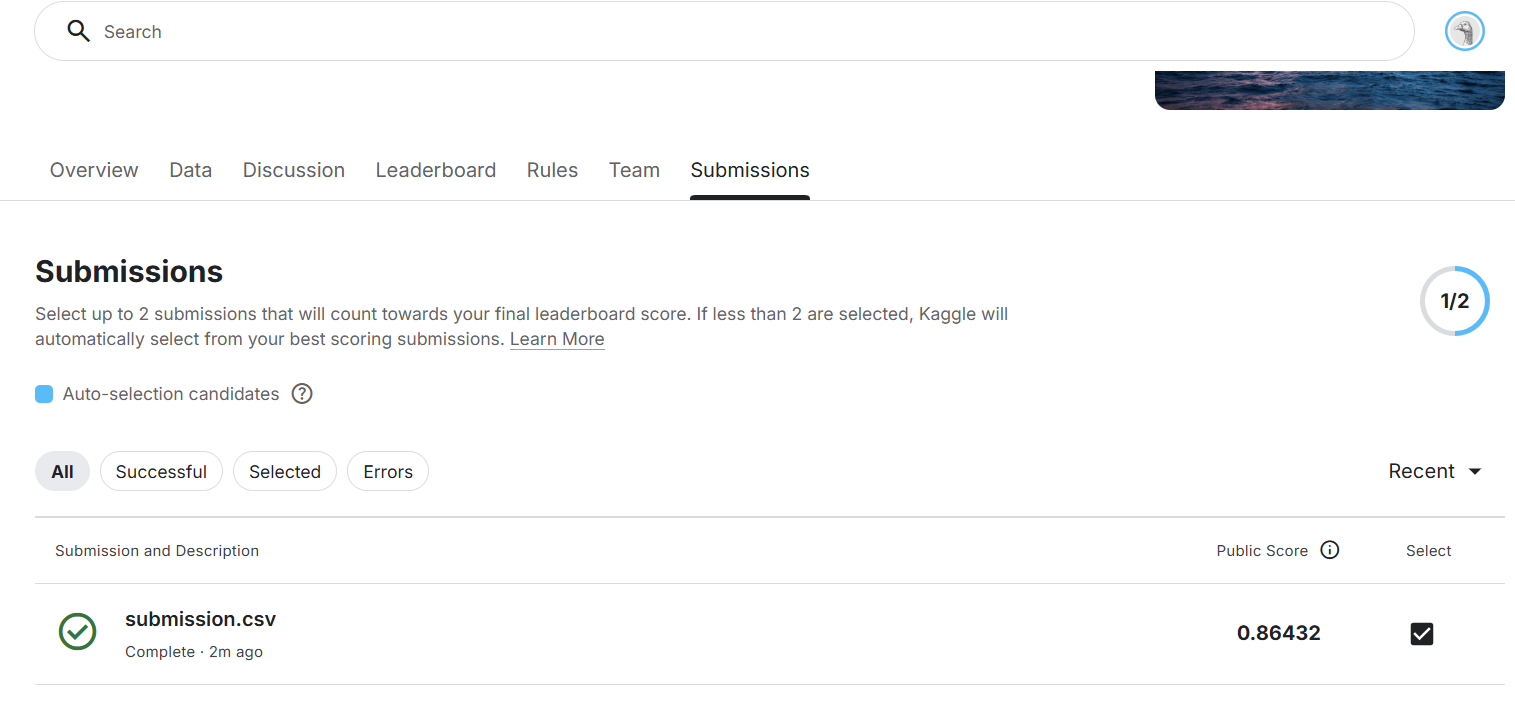

In [93]:
display(Image(filename='kaggle_result_Гришин.png'))